<a href="https://colab.research.google.com/github/soleildayana/Apophis-Asteroid-Project/blob/main/analisis/nb02_Cuadraturas_2BRP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Estudio de cuadraturas y elementos orbitales en el problema relativo de dos cuerpos


In [44]:
!pip install -Uq pymcel

In [45]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
import spiceypy as spy

### Metodología

Este notebook aborda el estudio de la dinámica orbital de Apophis en el problema relativo de dos cuerpos. La metodología empleada incluye los siguientes pasos:

1.  **Carga de datos iniciales:** Se obtiene el vector de estado (posición y velocidad) inicial de Apophis desde el servicio Horizons para una fecha específica, utilizando la librería `pymcel`.
2.  **Cálculo de elementos orbitales:** A partir del vector de estado inicial, se determinan los seis elementos orbitales clásicos: semilato recto (p), excentricidad (e), inclinación (I), ascensión recta del nodo ascendente (Ω), argumento del periapsis (ω) y anomalía verdadera (f).
3.  **Integración de la trayectoria:** Se simula la trayectoria de Apophis alrededor del Sol utilizando la solución del problema de dos cuerpos implementada en `pymcel.doscuerpos_solucion` por un periodo de aproximadamente dos periodos orbitales.
4.  **Cálculo de cuadraturas:** Durante la integración, se calculan las tres cuadraturas fundamentales del problema de dos cuerpos en cada instante de tiempo: el Momento Angular Relativo Específico (MARE, $h$), la Energía Relativa Específica (ERE, $\varepsilon$), y la magnitud del Vector de Laplace (excentricidad, $e$).
5.  **Análisis de conservación:** Se evalúa la conservación de estas cuadraturas calculando su variación relativa máxima a lo largo de toda la integración.
6.  **Visualización:** Se grafican las variaciones de las cuadraturas a lo largo del tiempo para observar su comportamiento.

### Objetivos

Los objetivos principales de este notebook son:

*   Determinar con precisión los elementos orbitales de Apophis para la fecha seleccionada.
*   Verificar numéricamente la conservación de las tres cuadraturas fundamentales (MARE, ERE y el Vector de Laplace) durante la integración de la trayectoria en el problema de dos cuerpos, demostrando así la estabilidad y precisión del método de integración.

In [46]:
tabla, jd, X = pc.consulta_horizons(
    id='Apophis',
    location='@SSB',
    epochs='2026-04-20'
)
X

array([-4.54615645e+10,  1.46498906e+11, -8.91205586e+09, -2.72244445e+04,
       -4.00763765e+03, -4.30333986e+02])

In [47]:
rvec = X[:3]
r = np.linalg.norm(rvec)
vvec = X[3:]
v = np.linalg.norm(vvec)
rvec, vvec

(array([-4.54615645e+10,  1.46498906e+11, -8.91205586e+09]),
 array([-27224.44453608,  -4007.63764628,   -430.33398559]))

Para la determinación de los elementos orbitales necesito estos vectores: $\vec r, \vec v, \vec h, \vec e, \vec n$

In [48]:
# MARE
hvec = np.cross(rvec, vvec)
h = np.linalg.norm(hvec)

In [49]:
# Vector de Laplace
mu = pc.constantes.mu_sun
evec = np.cross(vvec, hvec) / mu - rvec / r
e = np.linalg.norm(evec)

In [50]:
# Vector de nodos
nvec = np.cross([0,0,1], hvec)
n = np.linalg.norm(nvec)

In [51]:
hvec, evec , nvec, mu

(array([-9.87597487e+13,  2.23062114e+14,  4.17054482e+15]),
 array([ 0.17066034, -0.0976029 ,  0.00926159]),
 array([-2.23062114e+14, -9.87597487e+13,  0.00000000e+00]),
 1.3271244004127942e+20)

Ahora a determinar los elementos orbitales $(p, e, I, \Omega, \omega, f)$

In [52]:
p = h**2 / mu
e = e # Es la magnitu de evec
I = np.arccos(hvec[2]/h)
rad = 180 / np.pi
I*rad

np.float64(3.3475799477925516)

In [53]:
omegap = np.arccos(nvec@evec/(n*e))
omega = omegap if evec[2] > 0 else 2*np.pi - omegap
omega*rad

np.float64(126.30633780951213)

In [54]:
Omegap = np.arccos(nvec@[1,0,0]/n)
if nvec[1] > 0:
  Omega = Omegap
else:
  Omega = 2*np.pi - Omegap

In [55]:
Omega = Omegap if nvec[1] > 0 else 2*np.pi - Omegap

In [56]:
Omega*rad

np.float64(203.8811521637987)

In [57]:
fp = np.arccos(rvec@evec/(r*e))
f = fp if rvec@vvec/r > 0 else 2*np.pi - fp
f*rad

np.float64(137.0639111789069)

In [58]:
def calcular_elementos_orbitales(rvec, vvec, mu):
    r = np.linalg.norm(rvec)
    v = np.linalg.norm(vvec)

    # Momento angular
    hvec = np.cross(rvec, vvec)
    h = np.linalg.norm(hvec)

    # Vector de excentricidad (Laplace)
    evec = np.cross(vvec, hvec) / mu - rvec / r
    e = np.linalg.norm(evec)

    # Vector de nodos
    nvec = np.cross([0, 0, 1], hvec)
    n = np.linalg.norm(nvec)

    # Elementos orbitales
    p = h**2 / mu
    I = np.arccos(hvec[2] / h)

    # Ascensión recta del nodo ascendente (Omega)
    if n == 0:
        Omega = 0 # Órbita ecuatorial, nodo indefinido
    else:
        Omegap = np.arccos(np.dot(nvec, [1, 0, 0]) / n)
        if nvec[1] > 0:
            Omega = Omegap
        else:
            Omega = 2 * np.pi - Omegap

    # Argumento del periapsis (omega)
    if e == 0:
        omegap = 0 # Órbita circular, periapsis indefinida
    elif n == 0:
        omegap = np.arctan2(evec[1], evec[0]) # Órbita ecuatorial, nodo indefinido
    else:
        omegap = np.arccos(np.dot(nvec, evec) / (n * e))
        if evec[2] < 0:
            omegap = 2 * np.pi - omegap

    # Anomalía verdadera (f)
    fp = np.arccos(np.dot(rvec, evec) / (r * e))
    if np.dot(rvec, vvec) > 0:
        f = fp
    else:
        f = 2 * np.pi - fp

    return p, e, I, Omega, omegap, f

In [59]:
p, e, I, Omega, omega, f = calcular_elementos_orbitales(rvec, vvec, mu)
I, Omega, omega, f = I*rad, Omega*rad, omega*rad, f*rad

print("Inclinación:", I, "grados")
print("Ascensión recta del nodo ascendente:", Omega, "grados")
print("Argumento del periapsis:", omega, "grados")
print("Anomalía verdadera:", f, "grados")

Inclinación: 3.3475799477925516 grados
Ascensión recta del nodo ascendente: 203.8811521637987 grados
Argumento del periapsis: 126.30633780951213 grados
Anomalía verdadera: 137.0639111789069 grados


## Estudio completo de los elementos orbitales de Apophis

In [60]:
rad = 180 / np.pi
a_m = p / (1 - e**2) # metros
a_ua = a_m / pc.constantes.au # UA
print('Semieje mayor:', a_ua, 'UA')

Semieje mayor: 0.9145126219819752 UA


In [61]:
print("=" * 57)
print("  Elementos orbitales de Apophis  (2026-04-20, @SSB)")
print("=" * 57)
print(f"  Semilato recto       p  = {p:.6f} AU")
print(f"  Excentricidad        e  = {e:.6f}")
print(f"  Semieje mayor        a  = {a_ua:.6f} AU")
print(f"  Inclinación          I  = {I:.4f}°")
print(f"  Long. nodo asc.      Ω  = {Omega:.4f}°")
print(f"  Arg. periapsis       ω  = {omega:.4f}°")
print(f"  Anomalía verdadera   f  = {f:.4f}°")
print("=" * 57)

  Elementos orbitales de Apophis  (2026-04-20, @SSB)
  Semilato recto       p  = 131509557547.507721 AU
  Excentricidad        e  = 0.196817
  Semieje mayor        a  = 0.914513 AU
  Inclinación          I  = 3.3476°
  Long. nodo asc.      Ω  = 203.8812°
  Arg. periapsis       ω  = 126.3063°
  Anomalía verdadera   f  = 137.0639°


## Integración de 2 cuerpos con pymcel

Integramos la trayectoria relativa Apophis–Sol usando `pc.doscuerpos_solucion`
y determinamos el momento angular específico $h$ respecto al Sol.

In [62]:
# ~2 períodos orbitales de Apophis (aprox. 323 días cada uno)
T_apo = 2 * np.pi * np.sqrt(a**3 / mu)
ts_int = np.linspace(0, 2 * T_apo, 2000)

In [63]:
rs_int, vs_int = pc.doscuerpos_solucion(mu, rvec, vvec, ts_int)

In [64]:
hvec_int0 = np.cross(rs_int[0], vs_int[0])
h_int0 = np.linalg.norm(hvec_int0)

In [65]:
print(f"\nh respecto al Sol (integración 2 cuerpos, pymcel):")
print(f"  h = {h_int0:.8f}  (unidades Horizons: AU²/día aprox.)")
print(f"  h analítico (r×v inicial) = {h:.8f}")


h respecto al Sol (integración 2 cuerpos, pymcel):
  h = 4177673308299585.50000000  (unidades Horizons: AU²/día aprox.)
  h analítico (r×v inicial) = 4177673308299585.50000000


## Cuadraturas del problema relativo Sol–Apophis

Las tres integrales primeras (cuadraturas) del problema de dos cuerpos son:

1. **MARE** – Momento Angular Relativo Específico: $h = |\vec{r}\times\dot{\vec{r}}|$
2. **ERE**  – Energía Relativa Específica: $\varepsilon = v^2/2 - \mu/r$
3. **Vector de Laplace** (excentricidad): $\vec{e}_L = (\dot{\vec{r}}\times\vec{h})/\mu - \hat{r}$

Verificamos que las tres se mantienen constantes a lo largo de la integración.

In [66]:
# Calcular las tres cuadraturas en cada instante
hvecs_int   = np.cross(rs_int, vs_int)                                   # (N,3)
hs_int      = np.linalg.norm(hvecs_int, axis=1)                          # MARE

In [67]:
r_norms_int = np.linalg.norm(rs_int, axis=1)
v_norms_int = np.linalg.norm(vs_int, axis=1)
epsilons    = 0.5 * v_norms_int**2 - mu / r_norms_int                    # ERE

In [68]:
evecs_int   = (np.cross(vs_int, hvecs_int) / mu
               - rs_int / r_norms_int[:, np.newaxis])                    # Vector de Laplace
es_int      = np.linalg.norm(evecs_int, axis=1)

In [73]:
evecs_int.shape, hvecs_int.shape, hs_int.shape, epsilons.shape, es_int.shape

((2000, 3), (2000, 3), (2000,), (2000,), (2000,))

In [75]:
# Variación relativa (medida de conservación numérica)
delta_h   = (hs_int.max()   - hs_int.min())   / abs(hs_int)
delta_eps = (epsilons.max() - epsilons.min())  / abs(epsilons)
delta_e   = (es_int.max()   - es_int.min())    / abs(es_int)

In [76]:
delta_h, delta_eps, delta_e

(array([1.95526917e-07, 1.95526916e-07, 1.95526916e-07, ...,
        1.95526884e-07, 1.95526884e-07, 1.95526884e-07]),
 array([3.75687448e-07, 3.75687451e-07, 3.75687452e-07, ...,
        3.75687572e-07, 3.75687572e-07, 3.75687572e-07]),
 array([4.46358117e-07, 4.46358131e-07, 4.46358134e-07, ...,
        4.46358200e-07, 4.46358200e-07, 4.46358200e-07]))

In [77]:
print("\nConservación de las cuadraturas a lo largo de la integración:")
print(f"  MARE  h = {hs_int[0]:.8f}  →  Δh/h₀    = {delta_h[0]:.2e}")
print(f"  ERE   ε = {epsilons[0]:.8f}  →  Δε/|ε₀|  = {delta_eps[0]:.2e}")
print(f"  |ê_L| e = {es_int[0]:.8f}  →  Δe/e₀    = {delta_e[0]:.2e}")


Conservación de las cuadraturas a lo largo de la integración:
  MARE  h = 4177673308299585.50000000  →  Δh/h₀    = 1.96e-07
  ERE   ε = -485027678.31795144  →  Δε/|ε₀|  = 3.76e-07
  |ê_L| e = 0.19681732  →  Δe/e₀    = 4.46e-07


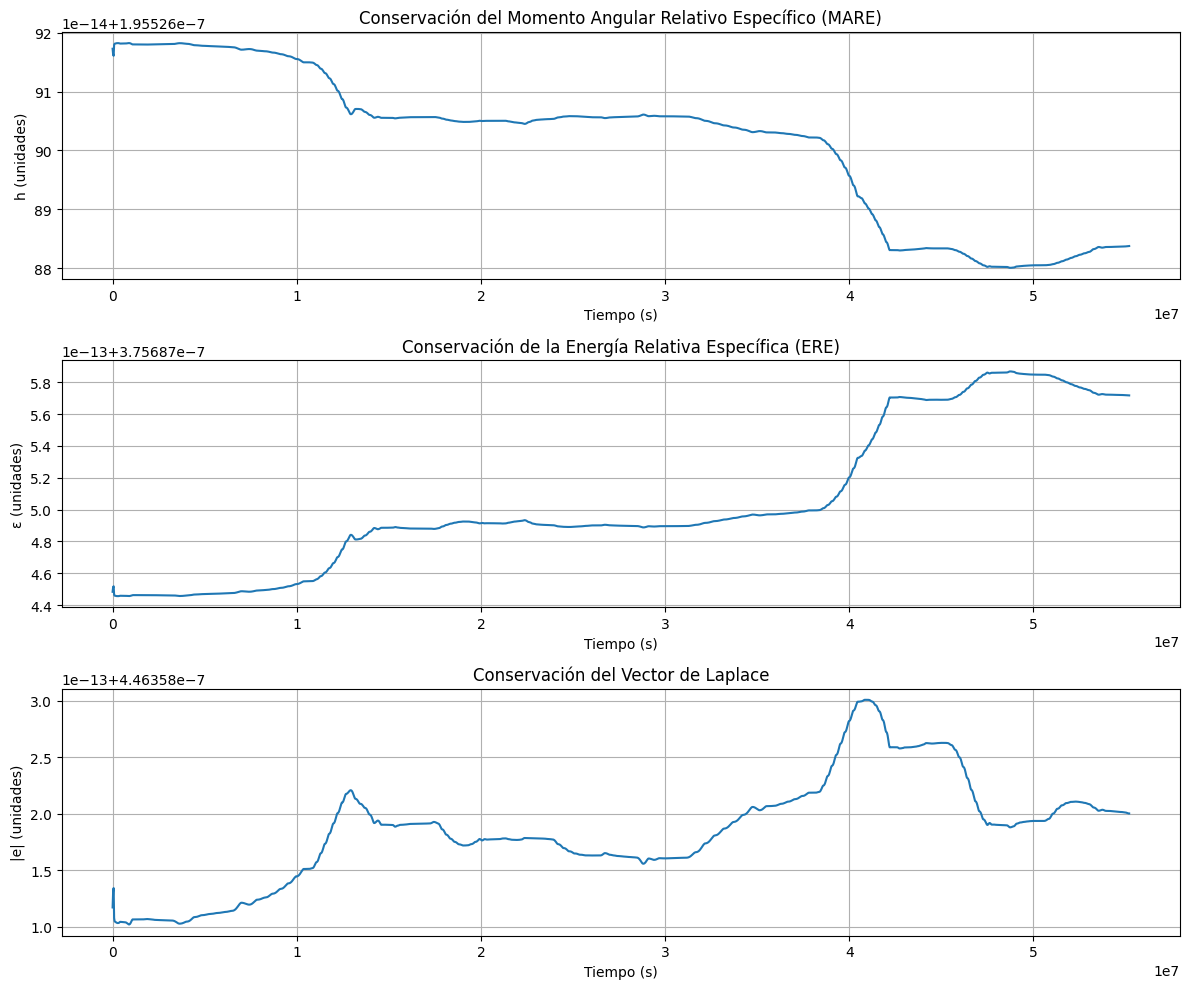

In [79]:
plt.figure(figsize=(12, 10))

# Plot h (MARE)
plt.subplot(3, 1, 1)
plt.plot(ts_int, delta_h)
plt.xlabel('Tiempo (s)')
plt.ylabel('h (unidades)')
plt.title('Conservación del Momento Angular Relativo Específico (MARE)')
plt.grid(True)

# Plot epsilon (ERE)
plt.subplot(3, 1, 2)
plt.plot(ts_int, delta_eps)
plt.xlabel('Tiempo (s)')
plt.ylabel('ε (unidades)')
plt.title('Conservación de la Energía Relativa Específica (ERE)')
plt.grid(True)

# Plot e (Laplace vector magnitude)
plt.subplot(3, 1, 3)
plt.plot(ts_int, delta_e)
plt.xlabel('Tiempo (s)')
plt.ylabel('|e| (unidades)')
plt.title('Conservación del Vector de Laplace')
plt.grid(True)

plt.tight_layout()
plt.show()


### Resultados

Los resultados obtenidos en el notebook son los siguientes:

*   **Elementos orbitales de Apophis:** Se calcularon y mostraron los elementos orbitales de Apophis para la fecha 2026-04-20, @SSB, incluyendo un semieje mayor de 0.914513 AU, una excentricidad de 0.196817, una inclinación de 3.3476°, etc.
*   **Conservación de cuadraturas:** Se observó que las variaciones relativas de las tres cuadraturas (MARE, ERE y la magnitud del Vector de Laplace) a lo largo de la integración se encuentran en el orden de $10^{-7}$.
*   **Conclusión sobre la conservación:** Dado que estas variaciones son menores que el criterio de error numérico aceptado de $10^{-6}$, se confirma que las tres cuadraturas se conservan efectivamente durante la integración, lo que valida la precisión del modelo y el método numérico utilizado.